In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None


# ============================================================
# 1. GENERAL SETTINGS
# ============================================================

DATASET = "V30"
DATATYPE = "Frequency"
UNIT = "cm^-1"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = (
    "cuda"
    if torch is not None and torch.cuda.is_available()
    else "cpu"
)

# IMPORTANT FOR V30:
# We are subtracting very similar total energies:
#
# E(+h) + E(-h) - 2 E(0)
#
# Therefore use float64.
DEFAULT_DTYPE = "float64"

EV_TO_KCAL_PER_MOL = 23.06054783
HARTREE_TO_KCAL_PER_MOL = 627.50947406


# ============================================================
# 2. FIND GSCDB ROOT
# ============================================================

def find_gscdb_root():
    current = Path.cwd().resolve()

    candidates = [
        current,
        current.parent,
        current.parent.parent,
    ]

    for root in candidates:
        required = [
            root / "Analysis",
            root / "Info",
            root / "xyz_files",
            root / "qchem_inputs",
        ]

        if all(path.exists() for path in required):
            return root

    raise FileNotFoundError(
        "Could not find the GSCDB root folder.\n"
        "Run this notebook either from the GSCDB root folder "
        "or from GSCDB/Analysis."
    )


ROOT = find_gscdb_root()

ANALYSIS_DIR = ROOT / "Analysis"
INFO_DIR = ROOT / "Info"
XYZ_DIR = ROOT / "xyz_files"
QCHEM_DIR = ROOT / "qchem_inputs"

FIGURES_DIR = ANALYSIS_DIR / "Figures"
FIGURES_DIR.mkdir(exist_ok=True)


# ============================================================
# 3. OUTPUT FILES
# ============================================================

MOLECULE_OUTPUT = (
    ANALYSIS_DIR /
    "Molecule_Energies_MACE_POLAR_V30_ALL3.csv"
)

REACTION_OUTPUT = (
    ANALYSIS_DIR /
    "Reaction_Energies_with_MACE_POLAR_V30_ALL3.csv"
)

VALUES_OUTPUT = (
    ANALYSIS_DIR /
    "Results_values_with_MACE_POLAR_V30_ALL3.csv"
)

ERRORS_OUTPUT = (
    ANALYSIS_DIR /
    "Results_errors_with_MACE_POLAR_V30_ALL3.csv"
)

METRICS_OUTPUT = (
    ANALYSIS_DIR /
    "V30_ALL3_metrics_RMSE_MAE_MRE.csv"
)

ERROR_LOG_OUTPUT = (
    ANALYSIS_DIR /
    "Molecule_Energies_MACE_POLAR_V30_ALL3_error_log.csv"
)


print("GSCDB ROOT :", ROOT)
print("DEVICE     :", DEVICE)
print("DTYPE      :", DEFAULT_DTYPE)
print("DATASET    :", DATASET)
print("DATATYPE   :", DATATYPE)
print("UNIT       :", UNIT)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
GSCDB ROOT : C:\Users\91988\GSCDB Benchmarking
DEVICE     : cpu
DTYPE      : float64
DATASET    : V30
DATATYPE   : Frequency
UNIT       : cm^-1


In [2]:
def convert_to_frequency(
    energy,
    step_size=0.01,
    input_in_kcal=True,
    output_in_cm=True,
):
    """
    Convert finite-difference energy to vibrational frequency.

    This reproduces the V30 conversion used in analyze.ipynb.

    Parameters
    ----------
    energy : float
        Finite-difference energy:
            E(+h) + E(-h) - 2E(0)

    step_size : float
        V30 finite-difference step from FD_stepsize.csv.

    input_in_kcal : bool
        True if energy is in kcal/mol.

    output_in_cm : bool
        True to return frequency in cm^-1.

    Returns
    -------
    float
        Signed vibrational frequency in cm^-1.

        Negative values are retained for imaginary frequencies.
    """

    constant_cm_to_hartree = 4.55633528e-6

    convert_force_constant_to_au = 1 / (
        (1.66053907e-27 / 9.10938370e-31)
        * (1 / 0.529177211) ** 2
    )

    fc = float(energy)

    # kcal/mol -> Hartree
    if input_in_kcal:
        fc /= 627.50947406

    # Preserve the sign.
    # Negative force constant -> imaginary frequency.
    signature = np.sign(fc)

    # Frequency calculation uses magnitude
    fc = np.abs(fc)

    # finite-difference second derivative
    fc /= step_size ** 2

    # force constant -> atomic units
    fc *= convert_force_constant_to_au

    # angular-frequency-type quantity
    freq = np.sqrt(fc)

    # atomic units -> cm^-1
    if output_in_cm:
        freq /= constant_cm_to_hartree

    # Restore imaginary-frequency sign
    freq *= signature

    return freq

In [4]:
def read_charge_and_spin(qchem_file):
    """
    Read charge and multiplicity from a Q-Chem input file.

    V30 geometries are normally neutral singlets, but reading the
    values from the original input avoids hard-coding assumptions.
    """

    charge = 0
    spin = 1

    if not qchem_file.exists():
        return charge, spin

    lines = qchem_file.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):

        if line.strip().lower() == "$molecule":

            j = i + 1

            while j < len(lines) and not lines[j].strip():
                j += 1

            if j < len(lines):
                parts = lines[j].split()

                if len(parts) >= 2:
                    charge = int(float(parts[0]))
                    spin = int(float(parts[1]))

            break

    return charge, spin


def prepare_v30_atoms(molecule_name):
    """
    Load one V30 geometry and prepare it for MACE-POLAR.

    IMPORTANT:
    V30 is a geometry finite-difference dataset.
    No external electric field is required.
    """

    xyz_file = XYZ_DIR / f"{molecule_name}.xyz"
    qchem_file = QCHEM_DIR / f"{molecule_name}.in"

    if not xyz_file.exists():
        raise FileNotFoundError(
            f"Missing xyz file: {xyz_file}"
        )

    charge, spin = read_charge_and_spin(qchem_file)

    atoms = read(xyz_file)

    # XYZ metadata can override qchem input if present
    if "charge" in atoms.info:
        charge = int(float(atoms.info["charge"]))

    if "multiplicity" in atoms.info:
        spin = int(float(atoms.info["multiplicity"]))

    elif "spin" in atoms.info:
        spin = int(float(atoms.info["spin"]))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin

    # V30 is NOT an electric-field dataset
    atoms.info["external_field"] = np.zeros(3, dtype=float)

    return atoms


def extract_molecules_from_stoichiometry(stoichiometry):
    """
    Extract molecular/geometry names from a GSCDB stoichiometry string.
    """

    parts = [
        x.strip()
        for x in str(stoichiometry).split(",")
    ]

    return parts[1::2]


def calculate_reaction_energy(
    stoichiometry,
    molecule_energy_df,
    model_column,
):
    """
    Reconstruct the raw V30 finite-difference energy.

    MACE energies:
        eV

    Returned value:
        kcal/mol
    """

    parts = [
        x.strip()
        for x in str(stoichiometry).split(",")
    ]

    reaction_energy_ev = 0.0

    for i in range(0, len(parts), 2):

        coefficient = float(parts[i])
        molecule_name = parts[i + 1]

        if molecule_name not in molecule_energy_df.index:
            return np.nan

        molecular_energy = molecule_energy_df.loc[
            molecule_name,
            model_column,
        ]

        if pd.isna(molecular_energy):
            return np.nan

        reaction_energy_ev += (
            coefficient * float(molecular_energy)
        )

    return reaction_energy_ev * EV_TO_KCAL_PER_MOL

In [5]:
# ============================================================
# LOAD ORIGINAL GSCDB FILES
# ============================================================

df_eval = pd.read_csv(
    INFO_DIR / "DatasetEval.csv",
    index_col=0,
)

df_dataset_info = pd.read_csv(
    INFO_DIR / "Datasets.csv",
    index_col=0,
)

df_steps = pd.read_csv(
    INFO_DIR / "FD_stepsize.csv",
    index_col=0,
)

df_reaction_base = pd.read_csv(
    ANALYSIS_DIR / "Reaction_Energies.csv",
    index_col=0,
)

df_values_base = pd.read_csv(
    ANALYSIS_DIR / "Results_values.csv",
    index_col=0,
)

df_standard = pd.read_csv(
    INFO_DIR / "Standard_errors.csv",
    index_col=0,
)

df_statistical = pd.read_csv(
    ANALYSIS_DIR / "Statistical_errors.csv",
    index_col=0,
)


# ============================================================
# SELECT V30
# ============================================================

df_eval_v30 = df_eval[
    df_eval["Dataset"] == DATASET
].copy()

v30_indices = df_eval_v30.index

df_reaction_v30_base = (
    df_reaction_base.loc[v30_indices].copy()
)

df_values_v30_base = (
    df_values_base.loc[v30_indices].copy()
)

v30_steps = (
    df_steps.loc[v30_indices, "fd step"]
    .astype(float)
)


# ============================================================
# BASIC CHECKS
# ============================================================

print("Dataset:", DATASET)
print("Datatype:", df_dataset_info.loc[DATASET, "Datatype"])

print(
    "Description:",
    df_dataset_info.loc[DATASET, "Description"]
)

print("\nNumber of V30 data points:")
print(len(df_eval_v30))

print("\nUnique V30 finite-difference steps:")
print(sorted(v30_steps.unique()))

print("\nStep-size distribution:")
print(v30_steps.value_counts().sort_index())

print("\nMissing step sizes:")
print(v30_steps.isna().sum())


assert len(df_eval_v30) == 275

assert v30_steps.isna().sum() == 0

Dataset: V30
Datatype: Frequency
Description: Frequencies of small molecular dimers with different polarity combinations (polar-polar, polar-nonpolar, and nonpolar-nonpolar).

Number of V30 data points:
275

Unique V30 finite-difference steps:
[np.float64(0.001), np.float64(0.003), np.float64(0.01)]

Step-size distribution:
fd step
0.001    155
0.003     78
0.010     42
Name: count, dtype: int64

Missing step sizes:
0


In [6]:
def convert_series_to_frequency(
    raw_energy_series,
    step_series,
):
    output = pd.Series(
        index=raw_energy_series.index,
        dtype=float,
    )

    for idx in raw_energy_series.index:

        energy = raw_energy_series.loc[idx]
        step = step_series.loc[idx]

        if pd.isna(energy):
            output.loc[idx] = np.nan
        else:
            output.loc[idx] = convert_to_frequency(
                energy,
                step_size=step,
                input_in_kcal=True,
                output_in_cm=True,
            )

    return output


# ============================================================
# RECONSTRUCT REFERENCE FREQUENCIES
# ============================================================

reference_reconstructed = convert_series_to_frequency(
    df_reaction_v30_base["Reference"],
    v30_steps,
)

wb97mv_reconstructed = convert_series_to_frequency(
    df_reaction_v30_base["wB97M-V"],
    v30_steps,
)


reference_difference = (
    reference_reconstructed
    - df_values_v30_base["Reference"]
)

wb97mv_difference = (
    wb97mv_reconstructed
    - df_values_v30_base["wB97M-V"]
)


print(
    "Maximum Reference conversion mismatch:",
    np.nanmax(np.abs(reference_difference)),
    "cm^-1",
)

print(
    "Maximum wB97M-V conversion mismatch:",
    np.nanmax(np.abs(wb97mv_difference)),
    "cm^-1",
)

Maximum Reference conversion mismatch: 9.094947017729282e-13 cm^-1
Maximum wB97M-V conversion mismatch: 9.094947017729282e-13 cm^-1


In [7]:
all_v30_molecules = sorted({
    molecule
    for stoich in df_eval_v30["Stoichiometry"]
    for molecule in extract_molecules_from_stoichiometry(stoich)
})


print("V30 frequency points:", len(df_eval_v30))

print(
    "Unique molecular/displaced geometries:",
    len(all_v30_molecules)
)

print("\nFirst 20 geometries:")
print(all_v30_molecules[:20])

V30 frequency points: 275
Unique molecular/displaced geometries: 580

First 20 geometries:
['V30_C2H2_Ar', 'V30_C2H2_Ar_1+', 'V30_C2H2_Ar_1-', 'V30_C2H2_Ar_2+', 'V30_C2H2_Ar_2-', 'V30_C2H2_Ar_3+', 'V30_C2H2_Ar_3-', 'V30_C2H2_Ar_4+', 'V30_C2H2_Ar_4-', 'V30_C2H2_Ar_5+', 'V30_C2H2_Ar_5-', 'V30_C2H2_Ar_6+', 'V30_C2H2_Ar_6-', 'V30_C2H2_Ar_7+', 'V30_C2H2_Ar_7-', 'V30_C2H2_Ar_8+', 'V30_C2H2_Ar_8-', 'V30_C2H2_C2H2', 'V30_C2H2_C2H2_1+', 'V30_C2H2_C2H2_1-']


In [8]:
# ============================================================
# RESUME-SAFE MOLECULAR ENERGY TABLE
# ============================================================

if MOLECULE_OUTPUT.exists():

    df_mace_molecules = pd.read_csv(
        MOLECULE_OUTPUT,
        index_col=0,
    )

    print(
        "Existing V30 molecular-energy file found."
    )

    print(
        "Already calculated values will be skipped."
    )

else:

    df_mace_molecules = pd.DataFrame(
        index=all_v30_molecules
    )


# Ensure all required geometries exist
for molecule in all_v30_molecules:

    if molecule not in df_mace_molecules.index:
        df_mace_molecules.loc[molecule, :] = np.nan


df_mace_molecules.index.name = "Molecule"


# ============================================================
# ERROR LOG
# ============================================================

error_log = []


# ============================================================
# RUN EACH MODEL SEPARATELY
# ============================================================

for output_column, model_name in MODELS.items():

    print("\n" + "=" * 70)
    print(
        f"Running {output_column} "
        f"using model={model_name}"
    )
    print("=" * 70)

    if output_column not in df_mace_molecules.columns:
        df_mace_molecules[output_column] = np.nan

    calc = mace_polar(
        model=model_name,
        device=DEVICE,
        default_dtype=DEFAULT_DTYPE,
    )

    for number, molecule_name in enumerate(
        tqdm(
            all_v30_molecules,
            desc=f"V30 | {output_column}",
        ),
        start=1,
    ):

        # Resume capability
        if pd.notna(
            df_mace_molecules.loc[
                molecule_name,
                output_column,
            ]
        ):
            continue

        try:

            atoms = prepare_v30_atoms(
                molecule_name
            )

            atoms.calc = calc

            energy_ev = float(
                atoms.get_potential_energy()
            )

            df_mace_molecules.loc[
                molecule_name,
                output_column,
            ] = energy_ev

        except Exception as exc:

            error_log.append({
                "Molecule": molecule_name,
                "Model": output_column,
                "Error": repr(exc),
            })

            df_mace_molecules.loc[
                molecule_name,
                output_column,
            ] = np.nan

        # Save progress periodically
        if number % 10 == 0:
            df_mace_molecules.to_csv(
                MOLECULE_OUTPUT
            )

    # Save after completing each model
    df_mace_molecules.to_csv(
        MOLECULE_OUTPUT
    )

    del calc
    gc.collect()

    if (
        torch is not None
        and torch.cuda.is_available()
    ):
        torch.cuda.empty_cache()


# ============================================================
# SAVE FINAL RESULTS
# ============================================================

df_mace_molecules.to_csv(
    MOLECULE_OUTPUT
)

pd.DataFrame(error_log).to_csv(
    ERROR_LOG_OUTPUT,
    index=False,
)


print("\nSaved:")
print(MOLECULE_OUTPUT)

print("\nMissing energies:")

print(
    df_mace_molecules[
        list(MODELS.keys())
    ].isna().sum()
)

print("\nError log:")
print(ERROR_LOG_OUTPUT)


Running mace-polar-1-s using model=polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
V30 | mace-polar-1-s: 100%|██████████| 580/580 [03:37<00:00,  2.66it/s]



Running mace-polar-1-m using model=polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
V30 | mace-polar-1-m: 100%|██████████| 580/580 [07:29<00:00,  1.29it/s]



Running mace-polar-1-l using model=polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
V30 | mace-polar-1-l: 100%|██████████| 580/580 [16:32<00:00,  1.71s/it]



Saved:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_V30_ALL3.csv

Missing energies:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

Error log:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_V30_ALL3_error_log.csv


In [9]:
df_reaction_v30 = (
    df_reaction_v30_base.copy()
)


for idx, row in tqdm(
    df_eval_v30.iterrows(),
    total=len(df_eval_v30),
    desc="Calculating V30 finite-difference energies",
):

    stoichiometry = row["Stoichiometry"]

    for model_column in MODELS:

        df_reaction_v30.loc[
            idx,
            model_column,
        ] = calculate_reaction_energy(
            stoichiometry,
            df_mace_molecules,
            model_column,
        )


df_reaction_v30.to_csv(
    REACTION_OUTPUT
)


print("\nSaved raw V30 finite-difference energies:")
print(REACTION_OUTPUT)


print("\nMACE finite-difference energy diagnostics:")

for model_column in MODELS:

    values = pd.to_numeric(
        df_reaction_v30[model_column],
        errors="coerce",
    )

    print("\n", model_column)

    print(
        "Missing:",
        values.isna().sum()
    )

    print(
        "Exact/near zero:",
        np.isclose(values, 0.0).sum()
    )

    print(
        "Minimum:",
        values.min()
    )

    print(
        "Maximum:",
        values.max()
    )

    print(
        "Negative force constants:",
        (values < 0).sum()
    )

Calculating V30 finite-difference energies: 100%|██████████| 275/275 [00:00<00:00, 612.94it/s]


Saved raw V30 finite-difference energies:
C:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_V30_ALL3.csv

MACE finite-difference energy diagnostics:

 mace-polar-1-s
Missing: 0
Exact/near zero: 0
Minimum: -0.0003941063203497108
Maximum: 0.0014926176560298397
Negative force constants: 28

 mace-polar-1-m
Missing: 0
Exact/near zero: 0
Minimum: -0.0003600882297597977
Maximum: 0.0014648312796304351
Negative force constants: 19

 mace-polar-1-l
Missing: 0
Exact/near zero: 0
Minimum: -0.00035819021678412335
Maximum: 0.0014584847148492398
Negative force constants: 19


In [10]:
df_values_v30 = (
    df_values_v30_base.copy()
)


for model_column in MODELS:

    converted_values = []

    for idx in df_reaction_v30.index:

        energy = df_reaction_v30.loc[
            idx,
            model_column,
        ]

        step_size = v30_steps.loc[idx]

        if pd.isna(energy):

            converted_values.append(np.nan)

        else:

            frequency = convert_to_frequency(
                energy,
                step_size=step_size,
                input_in_kcal=True,
                output_in_cm=True,
            )

            converted_values.append(
                frequency
            )

    df_values_v30[
        model_column
    ] = converted_values


df_values_v30.to_csv(
    VALUES_OUTPUT
)


print("\nSaved converted V30 frequencies:")
print(VALUES_OUTPUT)


print("\nFrequency ranges:")

for model_column in [
    "Reference",
    "wB97M-V",
    *MODELS.keys(),
]:

    values = pd.to_numeric(
        df_values_v30[model_column],
        errors="coerce",
    )

    print(
        f"{model_column:20s} "
        f"min={values.min():12.4f} "
        f"max={values.max():12.4f} "
        f"negative={(values < 0).sum():3d}"
    )


Saved converted V30 frequencies:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_V30_ALL3.csv

Frequency ranges:
Reference            min=     28.7272 max=   4124.0855 negative=  0
wB97M-V              min=   -177.2211 max=   4128.5687 negative=  2
mace-polar-1-s       min=   -378.1451 max=   4195.3631 negative= 28
mace-polar-1-m       min=   -371.2412 max=   4156.1295 negative= 19
mace-polar-1-l       min=   -252.0842 max=   4147.1162 negative= 19


In [11]:
df_errors_v30 = (
    df_values_v30.copy()
)


for model_column in [
    c for c in df_values_v30.columns
    if c not in [
        "Dataset",
        "Reaction",
        "Reference",
    ]
]:

    df_errors_v30[model_column] = (
        pd.to_numeric(
            df_values_v30[model_column],
            errors="coerce",
        )
        -
        pd.to_numeric(
            df_values_v30["Reference"],
            errors="coerce",
        )
    )


df_errors_v30.to_csv(
    ERRORS_OUTPUT
)


print("Saved V30 errors:")
print(ERRORS_OUTPUT)

Saved V30 errors:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_V30_ALL3.csv


In [12]:
# ============================================================
# STANDARD V30 BENCHMARK ERROR
# ============================================================

V30_STANDARD_METRIC = float(
    df_standard.loc["V30", "Metric"]
)

V30_STANDARD_MAE = float(
    df_standard.loc["V30", "MAE"]
)

V30_STANDARD_RMSE = float(
    df_standard.loc["V30", "RMSE"]
)


print("V30 Standard_errors.csv values")
print("--------------------------------")

print(
    f"Metric = {V30_STANDARD_METRIC:.9f} cm^-1"
)

print(
    f"MAE    = {V30_STANDARD_MAE:.9f} cm^-1"
)

print(
    f"RMSE   = {V30_STANDARD_RMSE:.9f} cm^-1"
)


# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_v30_metrics(reference, prediction):

    data = pd.DataFrame({
        "Reference": pd.to_numeric(
            reference,
            errors="coerce",
        ),
        "Prediction": pd.to_numeric(
            prediction,
            errors="coerce",
        ),
    }).dropna()

    x = data["Reference"].to_numpy(float)
    y = data["Prediction"].to_numpy(float)

    error = y - x

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    mae = np.mean(
        np.abs(error)
    )

    # ========================================================
    # THIS IS THE GSCDB MEAN RELATIVE ERROR / NER
    # ========================================================
    #
    # V30 metric = MAE
    #
    # relative metric = model MAE / V30 standard metric
    #
    # Because V30 is the ONLY Frequency dataset,
    # Mean Frequency = this value directly.
    # ========================================================

    mre = mae / V30_STANDARD_METRIC

    if len(x) > 1:
        pearson_r = np.corrcoef(
            x,
            y,
        )[0, 1]
    else:
        pearson_r = np.nan

    return {
        "N": len(x),
        "RMSE": rmse,
        "MAE": mae,
        "MRE": mre,
        "Pearson_r": pearson_r,
    }


# ============================================================
# CALCULATE METRICS
# ============================================================

metric_rows = []

models_for_metrics = [
    "wB97M-V",
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]


for model_column in models_for_metrics:

    result = calculate_v30_metrics(
        df_values_v30["Reference"],
        df_values_v30[model_column],
    )

    metric_rows.append({
        "Dataset": "V30",
        "Datatype": "Frequency",
        "Model": model_column,
        "Unit": "cm^-1",
        **result,
    })


df_metrics = pd.DataFrame(
    metric_rows
)


df_metrics.to_csv(
    METRICS_OUTPUT,
    index=False,
)


print("\nV30 Frequency metrics")
print("=====================")

print(
    df_metrics.to_string(index=False)
)


print("\nSaved metrics:")
print(METRICS_OUTPUT)

V30 Standard_errors.csv values
--------------------------------
Metric = 30.049781000 cm^-1
MAE    = 30.049781000 cm^-1
RMSE   = 48.214375291 cm^-1

V30 Frequency metrics
Dataset  Datatype          Model  Unit   N       RMSE       MAE      MRE  Pearson_r
    V30 Frequency        wB97M-V cm^-1 275  48.208634 27.787819 0.924726   0.999388
    V30 Frequency mace-polar-1-s cm^-1 275 103.150998 53.556929 1.782274   0.997580
    V30 Frequency mace-polar-1-m cm^-1 275  90.163619 45.501520 1.514205   0.998062
    V30 Frequency mace-polar-1-l cm^-1 275  87.959332 45.813113 1.524574   0.998157

Saved metrics:
C:\Users\91988\GSCDB Benchmarking\Analysis\V30_ALL3_metrics_RMSE_MAE_MRE.csv


In [13]:
# ============================================================
# DIRECT COMPARISON WITH Statistical_errors.csv
# ============================================================

frequency_row_name = "Mean Frequency"


if frequency_row_name not in df_statistical.index:
    raise KeyError(
        f"'{frequency_row_name}' not found "
        "in Statistical_errors.csv"
    )


print(
    "\nComparison with existing Statistical_errors.csv"
)

print("=" * 70)


for model_column in ["wB97M-V"]:

    calculated_mre = float(
        df_metrics.loc[
            df_metrics["Model"] == model_column,
            "MRE",
        ].iloc[0]
    )

    statistical_mre = float(
        df_statistical.loc[
            frequency_row_name,
            model_column,
        ]
    )

    difference = (
        calculated_mre
        - statistical_mre
    )

    print(f"\nModel: {model_column}")

    print(
        f"Calculated MRE     = "
        f"{calculated_mre:.12f}"
    )

    print(
        f"Statistical_errors = "
        f"{statistical_mre:.12f}"
    )

    print(
        f"Difference         = "
        f"{difference:.12e}"
    )

    if np.isclose(
        calculated_mre,
        statistical_mre,
        rtol=1e-10,
        atol=1e-12,
    ):
        print("MATCH: YES")
    else:
        print("MATCH: NO")


Comparison with existing Statistical_errors.csv

Model: wB97M-V
Calculated MRE     = 0.924726166642
Statistical_errors = 0.924726166642
Difference         = 4.440892098501e-16
MATCH: YES


In [14]:
df_statistical_extended = (
    df_statistical.copy()
)


for model_column in MODELS:

    if model_column not in df_statistical_extended.columns:

        df_statistical_extended[
            model_column
        ] = np.nan

    model_mre = float(
        df_metrics.loc[
            df_metrics["Model"] == model_column,
            "MRE",
        ].iloc[0]
    )

    df_statistical_extended.loc[
        "Mean Frequency",
        model_column,
    ] = model_mre


statistical_output = (
    ANALYSIS_DIR /
    "Statistical_errors_with_MACE_POLAR_V30_Frequency.csv"
)


df_statistical_extended.to_csv(
    statistical_output
)


print("\nSaved:")
print(statistical_output)


print("\nMean Frequency row:")
print(
    df_statistical_extended.loc[
        "Mean Frequency",
        [
            "wB97M-V",
            "mace-polar-1-s",
            "mace-polar-1-m",
            "mace-polar-1-l",
        ],
    ]
)


Saved:
C:\Users\91988\GSCDB Benchmarking\Analysis\Statistical_errors_with_MACE_POLAR_V30_Frequency.csv

Mean Frequency row:
wB97M-V           0.924726
mace-polar-1-s    1.782274
mace-polar-1-m    1.514205
mace-polar-1-l    1.524574
Name: Mean Frequency, dtype: float64


In [15]:
MODEL_LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}


def get_plot_limits(*series):

    values = np.concatenate([
        pd.to_numeric(
            s,
            errors="coerce",
        )
        .dropna()
        .to_numpy(float)

        for s in series
    ])

    minimum = values.min()
    maximum = values.max()

    value_range = maximum - minimum

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    return (
        minimum - padding,
        maximum + padding,
    )


def plot_v30_reference_vs_wb97mv_and_mace(
    df,
    mace_model,
):

    required_columns = [
        "Reference",
        "wB97M-V",
        mace_model,
    ]

    selected = (
        df[required_columns]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .dropna()
    )

    reference = selected["Reference"]

    wb97mv = selected["wB97M-V"]

    mace = selected[mace_model]


    # ========================================================
    # METRICS
    # ========================================================

    wb_metrics = calculate_v30_metrics(
        reference,
        wb97mv,
    )

    mace_metrics = calculate_v30_metrics(
        reference,
        mace,
    )


    print("\n" + "=" * 70)

    print(
        f"V30 | Frequency | {mace_model}"
    )

    print("=" * 70)

    print("\nwB97M-V")

    print(
        f"RMSE = {wb_metrics['RMSE']:.6f} cm^-1"
    )

    print(
        f"MAE  = {wb_metrics['MAE']:.6f} cm^-1"
    )

    print(
        f"MRE  = {wb_metrics['MRE']:.6f}"
    )


    print(f"\n{mace_model}")

    print(
        f"RMSE = {mace_metrics['RMSE']:.6f} cm^-1"
    )

    print(
        f"MAE  = {mace_metrics['MAE']:.6f} cm^-1"
    )

    print(
        f"MRE  = {mace_metrics['MRE']:.6f}"
    )


    # ========================================================
    # LIMITS
    # ========================================================

    plot_min, plot_max = get_plot_limits(
        reference,
        wb97mv,
        mace,
    )


    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(
        figsize=(8, 7)
    )


    plt.scatter(
        reference,
        wb97mv,
        s=40,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.25,
        label=(
            "wB97M-V\n"
            f"RMSE={wb_metrics['RMSE']:.2f}, "
            f"MAE={wb_metrics['MAE']:.2f}, "
            f"MRE={wb_metrics['MRE']:.3f}"
        ),
    )


    plt.scatter(
        reference,
        mace,
        s=40,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.25,
        label=(
            f"{MODEL_LABELS[mace_model]}\n"
            f"RMSE={mace_metrics['RMSE']:.2f}, "
            f"MAE={mace_metrics['MAE']:.2f}, "
            f"MRE={mace_metrics['MRE']:.3f}"
        ),
    )


    # Perfect agreement
    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "--",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )


    plt.xlim(
        plot_min,
        plot_max,
    )

    plt.ylim(
        plot_min,
        plot_max,
    )

    plt.gca().set_aspect(
        "equal",
        adjustable="box",
    )


    plt.xlabel(
        r"Reference vibrational frequency (cm$^{-1}$)",
        fontsize=12,
    )

    plt.ylabel(
        r"Calculated vibrational frequency (cm$^{-1}$)",
        fontsize=12,
    )


    plt.title(
        "Dataset: V30 | Datatype: Frequency\n"
        f"Reference vs wB97M-V and "
        f"{MODEL_LABELS[mace_model]}",
        fontsize=12,
        fontweight="bold",
    )


    plt.grid(
        alpha=0.30
    )

    plt.legend(
        fontsize=9
    )

    plt.tight_layout()


    output_plot = (
        FIGURES_DIR /
        (
            "V30_Reference_vs_wB97MV_and_"
            f"{mace_model}_RMSE_MAE_MRE.png"
        )
    )


    plt.savefig(
        output_plot,
        dpi=300,
        bbox_inches="tight",
    )


    print("\nSaved plot:")
    print(output_plot)


    plt.show()


    return {
        "Dataset": "V30",
        "Datatype": "Frequency",

        "DFT_Model": "wB97M-V",

        "DFT_RMSE": wb_metrics["RMSE"],
        "DFT_MAE": wb_metrics["MAE"],
        "DFT_MRE": wb_metrics["MRE"],
        "DFT_Pearson_r": wb_metrics["Pearson_r"],

        "MACE_Model": mace_model,

        "MACE_RMSE": mace_metrics["RMSE"],
        "MACE_MAE": mace_metrics["MAE"],
        "MACE_MRE": mace_metrics["MRE"],
        "MACE_Pearson_r": mace_metrics["Pearson_r"],

        "N": len(selected),
    }


V30 | Frequency | mace-polar-1-s

wB97M-V
RMSE = 48.208634 cm^-1
MAE  = 27.787819 cm^-1
MRE  = 0.924726

mace-polar-1-s
RMSE = 103.150998 cm^-1
MAE  = 53.556929 cm^-1
MRE  = 1.782274

Saved plot:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\V30_Reference_vs_wB97MV_and_mace-polar-1-s_RMSE_MAE_MRE.png


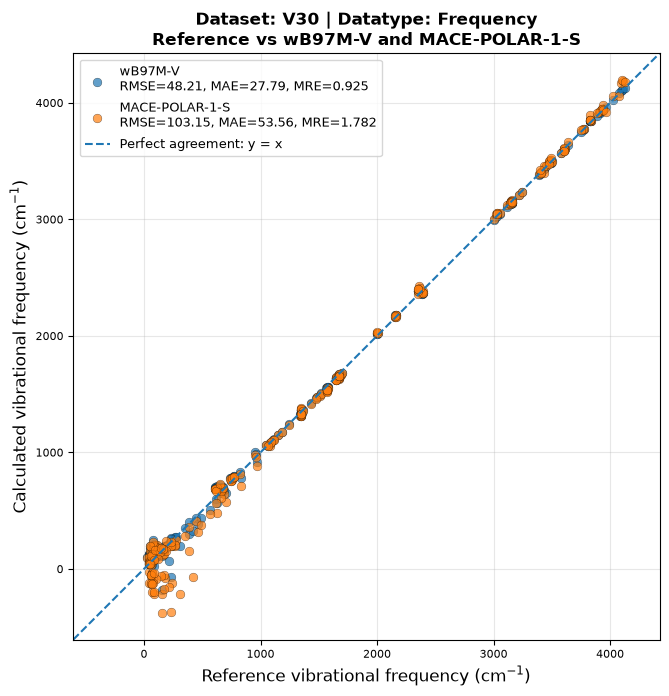


V30 | Frequency | mace-polar-1-m

wB97M-V
RMSE = 48.208634 cm^-1
MAE  = 27.787819 cm^-1
MRE  = 0.924726

mace-polar-1-m
RMSE = 90.163619 cm^-1
MAE  = 45.501520 cm^-1
MRE  = 1.514205

Saved plot:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\V30_Reference_vs_wB97MV_and_mace-polar-1-m_RMSE_MAE_MRE.png


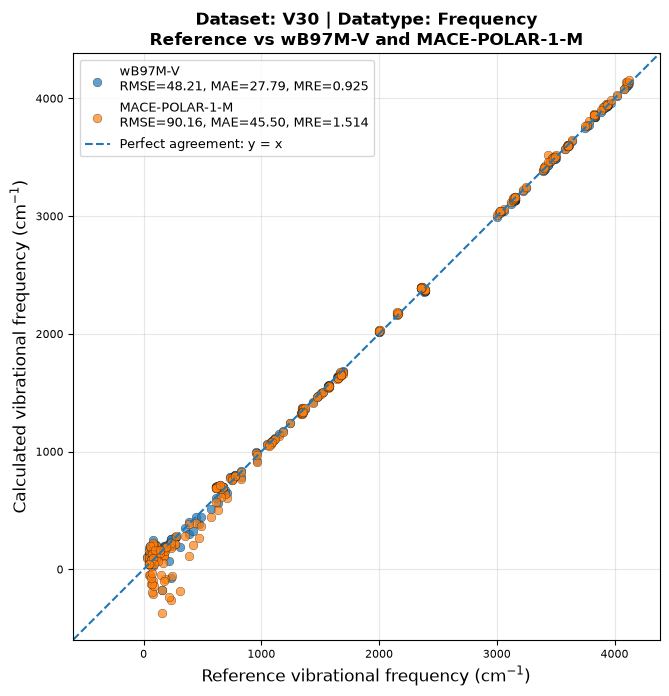


V30 | Frequency | mace-polar-1-l

wB97M-V
RMSE = 48.208634 cm^-1
MAE  = 27.787819 cm^-1
MRE  = 0.924726

mace-polar-1-l
RMSE = 87.959332 cm^-1
MAE  = 45.813113 cm^-1
MRE  = 1.524574

Saved plot:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\V30_Reference_vs_wB97MV_and_mace-polar-1-l_RMSE_MAE_MRE.png


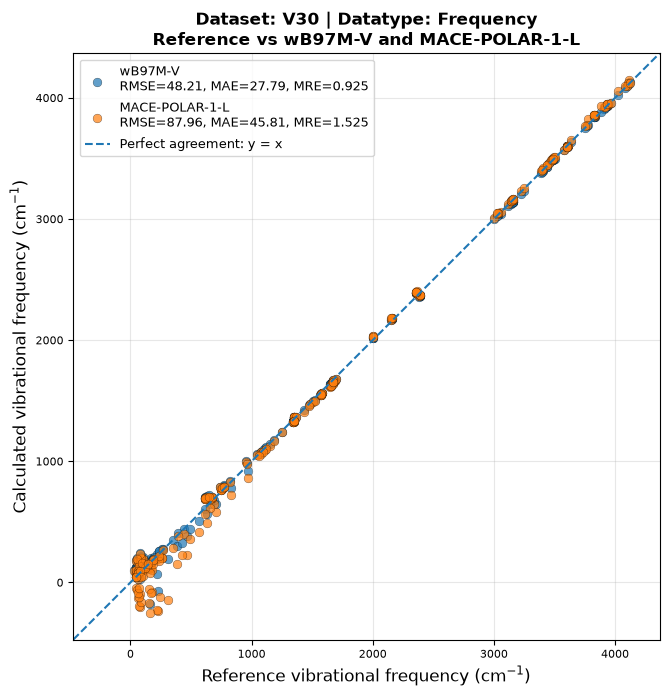


All V30 plotting metrics:
Dataset  Datatype DFT_Model  DFT_RMSE   DFT_MAE  DFT_MRE  DFT_Pearson_r     MACE_Model  MACE_RMSE  MACE_MAE  MACE_MRE  MACE_Pearson_r   N
    V30 Frequency   wB97M-V 48.208634 27.787819 0.924726       0.999388 mace-polar-1-s 103.150998 53.556929  1.782274        0.997580 275
    V30 Frequency   wB97M-V 48.208634 27.787819 0.924726       0.999388 mace-polar-1-m  90.163619 45.501520  1.514205        0.998062 275
    V30 Frequency   wB97M-V 48.208634 27.787819 0.924726       0.999388 mace-polar-1-l  87.959332 45.813113  1.524574        0.998157 275

Saved summary:
C:\Users\91988\GSCDB Benchmarking\Analysis\V30_Reference_vs_wB97MV_and_MACE_ALL3_summary.csv


In [16]:
plot_results = []


for mace_model in [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]:

    result = (
        plot_v30_reference_vs_wb97mv_and_mace(
            df_values_v30,
            mace_model,
        )
    )

    plot_results.append(
        result
    )


df_plot_summary = pd.DataFrame(
    plot_results
)


plot_summary_output = (
    ANALYSIS_DIR /
    "V30_Reference_vs_wB97MV_and_MACE_ALL3_summary.csv"
)


df_plot_summary.to_csv(
    plot_summary_output,
    index=False,
)


print("\nAll V30 plotting metrics:")
print(
    df_plot_summary.to_string(
        index=False
    )
)


print("\nSaved summary:")
print(plot_summary_output)

In [17]:
comparison_table = (
    df_metrics[
        [
            "Model",
            "N",
            "RMSE",
            "MAE",
            "MRE",
            "Pearson_r",
        ]
    ]
    .copy()
)


comparison_table["Standard_Metric"] = (
    V30_STANDARD_METRIC
)


comparison_table["Better_than_standard"] = (
    comparison_table["MRE"] < 1.0
)


comparison_table = (
    comparison_table
    .sort_values(
        "MRE",
        ascending=True,
    )
    .reset_index(drop=True)
)


print(
    "\nV30 FREQUENCY — FINAL COMPARISON"
)

print("=" * 100)

print(
    comparison_table.to_string(
        index=False
    )
)


final_comparison_file = (
    ANALYSIS_DIR /
    "V30_MACE_POLAR_FINAL_COMPARISON.csv"
)


comparison_table.to_csv(
    final_comparison_file,
    index=False,
)


print("\nSaved:")
print(final_comparison_file)


V30 FREQUENCY — FINAL COMPARISON
         Model   N       RMSE       MAE      MRE  Pearson_r  Standard_Metric  Better_than_standard
       wB97M-V 275  48.208634 27.787819 0.924726   0.999388        30.049781                  True
mace-polar-1-m 275  90.163619 45.501520 1.514205   0.998062        30.049781                 False
mace-polar-1-l 275  87.959332 45.813113 1.524574   0.998157        30.049781                 False
mace-polar-1-s 275 103.150998 53.556929 1.782274   0.997580        30.049781                 False

Saved:
C:\Users\91988\GSCDB Benchmarking\Analysis\V30_MACE_POLAR_FINAL_COMPARISON.csv


In [18]:
# V30: MACE-POLAR frequencies + RMSE/MAE/MRE


from pathlib import Path
import gc, numpy as np, pandas as pd
from tqdm.auto import tqdm
from ase.io import read
from mace.calculators import mace_polar
import torch

# ---------- Paths / settings ----------
ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A, I, X, Q = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files", ROOT/"qchem_inputs"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l"
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EV2KCAL = 23.06054783

# ---------- Load GSCDB data ----------
eval_df = pd.read_csv(I/"DatasetEval.csv", index_col=0)
steps = pd.read_csv(I/"FD_stepsize.csv", index_col=0)["fd step"]
reaction = pd.read_csv(A/"Reaction_Energies.csv", index_col=0)
values = pd.read_csv(A/"Results_values.csv", index_col=0)
standard = pd.read_csv(I/"Standard_errors.csv", index_col=0)
stat = pd.read_csv(A/"Statistical_errors.csv", index_col=0)
metric_old = pd.read_csv(A/"Errors_per_set_Metric.csv", index_col=0)
relative_old = pd.read_csv(A/"Relative_metric_per_set.csv", index_col=0)

idx = eval_df.index[eval_df["Dataset"].eq("V30")]
v30 = eval_df.loc[idx].copy()
steps = pd.to_numeric(steps.reindex(idx), errors="coerce")
reaction_v30, values_v30 = reaction.loc[idx].copy(), values.loc[idx].copy()

# ---------- Exact conversion used in analyze.ipynb ----------
def to_freq(E, h):
    fc = E / 627.50947406
    sign = np.sign(fc)
    fc = abs(fc) / h**2
    fc *= 1 / ((1.66053907e-27/9.10938370e-31) * (1/0.529177211)**2)
    return sign * np.sqrt(fc) / 4.55633528e-6

# ---------- Stoichiometry / molecular information ----------
def parse_stoich(s):
    p = [x.strip() for x in str(s).split(",") if x.strip()]
    return [(float(p[i]), p[i+1]) for i in range(0, len(p), 2)]

def get_atoms(name):
    atoms = read(X/f"{name}.xyz")
    charge, spin = 0, 1
    qfile = Q/f"{name}.in"
    if qfile.exists():
        lines = qfile.read_text(errors="ignore").splitlines()
        for i, line in enumerate(lines):
            if line.strip().lower() == "$molecule":
                p = lines[i+1].split()
                if len(p) >= 2:
                    charge, spin = int(float(p[0])), int(float(p[1]))
                break
    atoms.info["charge"] = int(atoms.info.get("charge", charge))
    atoms.info["spin"] = int(atoms.info.get("multiplicity", atoms.info.get("spin", spin)))
    atoms.info["external_field"] = np.zeros(3)
    return atoms

molecules = sorted({
    mol for s in v30["Stoichiometry"]
    for _, mol in parse_stoich(s)
})

print(f"V30 points: {len(v30)} | Unique geometries: {len(molecules)}")
print("FD steps:", steps.value_counts().sort_index().to_dict())
print("Device:", DEVICE)

# ---------- MACE-POLAR molecular energies ----------
mol_file = A/"Molecule_Energies_MACE_POLAR_V30_ALL3_FLOAT64.csv"
molE = pd.read_csv(mol_file, index_col=0).reindex(molecules) if mol_file.exists() else pd.DataFrame(index=molecules)

for col, model in MODELS.items():
    if col not in molE: molE[col] = np.nan
    calc = mace_polar(model=model, device=DEVICE, default_dtype="float64")

    for name in tqdm(molecules, desc=col):
        if pd.isna(molE.at[name, col]):
            atoms = get_atoms(name)
            atoms.calc = calc
            molE.at[name, col] = atoms.get_potential_energy()

    molE.to_csv(mol_file)
    del calc
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---------- E(+h)+E(-h)-2E(0) -> kcal/mol -> cm^-1 ----------
for col in MODELS:
    reaction_v30[col] = [
        sum(c * molE.at[m, col] for c, m in parse_stoich(v30.at[i, "Stoichiometry"])) * EV2KCAL
        for i in idx
    ]
    values_v30[col] = [
        to_freq(reaction_v30.at[i, col], steps.at[i])
        for i in idx
    ]

reaction_v30.to_csv(A/"Reaction_Energies_with_MACE_POLAR_V30_ALL3.csv")
values_v30.to_csv(A/"Results_values_with_MACE_POLAR_V30_ALL3.csv")

# ---------- Point-wise errors ----------
plot_models = [
    "wB97M-V",
    "revDSD-PBEP86-D4",
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

errors_v30 = values_v30.copy()
for col in plot_models:
    errors_v30[col] = values_v30[col] - values_v30["Reference"]

errors_v30.to_csv(A/"Results_errors_with_MACE_POLAR_V30_ALL3.csv")

# ---------- RMSE, MAE, MRE ----------
# V30 benchmark Metric = MAE; V30 is the only Frequency dataset.
STD = float(standard.at["V30", "Metric"])

def metrics(col):
    d = values_v30[["Reference", col]].apply(pd.to_numeric, errors="coerce").dropna()
    ref, pred = d["Reference"].to_numpy(), d[col].to_numpy()
    err = pred - ref
    mae = np.mean(abs(err))
    return len(d), np.sqrt(np.mean(err**2)), mae, mae/STD, np.corrcoef(ref, pred)[0,1]

rows = []
for col in plot_models:
    n, rmse, mae, mre, r = metrics(col)
    rows.append([col, n, rmse, mae, mre, r])

metrics_df = pd.DataFrame(
    rows,
    columns=["Model", "N", "RMSE_cm-1", "MAE_cm-1", "MRE", "Pearson_r"]
)
metrics_df.to_csv(A/"V30_Frequency_RMSE_MAE_MRE_ALL_MODELS.csv", index=False)

# ---------- Match original Statistical_errors.csv ----------
print("\nMRE validation against Statistical_errors.csv")
for col in ["wB97M-V", "revDSD-PBEP86-D4"]:
    calc_mre = metrics_df.loc[metrics_df.Model.eq(col), "MRE"].iloc[0]
    old_mre = float(stat.at["Mean Frequency", col])
    print(f"{col:20s}: calculated={calc_mre:.12f} | file={old_mre:.12f} | match={np.isclose(calc_mre, old_mre)}")

# ---------- Extended benchmark tables ----------
metric_new, relative_new, stat_new = metric_old.copy(), relative_old.copy(), stat.copy()

for col in MODELS:
    mae = metrics_df.loc[metrics_df.Model.eq(col), "MAE_cm-1"].iloc[0]
    mre = metrics_df.loc[metrics_df.Model.eq(col), "MRE"].iloc[0]
    metric_new.loc["V30", col] = mae
    relative_new.loc["V30", col] = mre
    stat_new.loc["Mean Frequency", col] = mre

metric_new.to_csv(A/"Errors_per_set_Metric_with_MACE_POLAR_V30.csv")
relative_new.to_csv(A/"Relative_metric_per_set_with_MACE_POLAR_V30.csv")
stat_new.to_csv(A/"Statistical_errors_with_MACE_POLAR_V30.csv")

final = metrics_df.sort_values("MRE").reset_index(drop=True)
final["Better_than_standard"] = final["MRE"] < 1
final.to_csv(A/"V30_FINAL_COMPARISON_DFT_and_MACE_POLAR.csv", index=False)

print("\nV30 FINAL RESULTS")
display(final)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


V30 points: 275 | Unique geometries: 580
FD steps: {0.001: 155, 0.003: 78, 0.01: 42}
Device: cpu
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 580/580 [03:08<00:00,  3.07it/s]


Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-m: 100%|██████████| 580/580 [05:53<00:00,  1.64it/s]


Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-l: 100%|██████████| 580/580 [13:20<00:00,  1.38s/it]



MRE validation against Statistical_errors.csv
wB97M-V             : calculated=0.924726166642 | file=0.924726166642 | match=True
revDSD-PBEP86-D4    : calculated=0.326404230809 | file=0.326404230809 | match=True

V30 FINAL RESULTS


,Model,N,RMSE_cm-1,MAE_cm-1,MRE,Pearson_r,Better_than_standard
0,revDSD-PBEP86-D4,275,15.066591,9.808376,0.326404,0.999940,True
1,wB97M-V,275,48.208634,27.787819,0.924726,0.999388,True
2,mace-polar-1-m,275,90.163619,45.501520,1.514205,0.998062,False
3,mace-polar-1-l,275,87.959332,45.813113,1.524574,0.998157,False
4,mace-polar-1-s,275,103.150998,53.556929,1.782274,0.997580,False


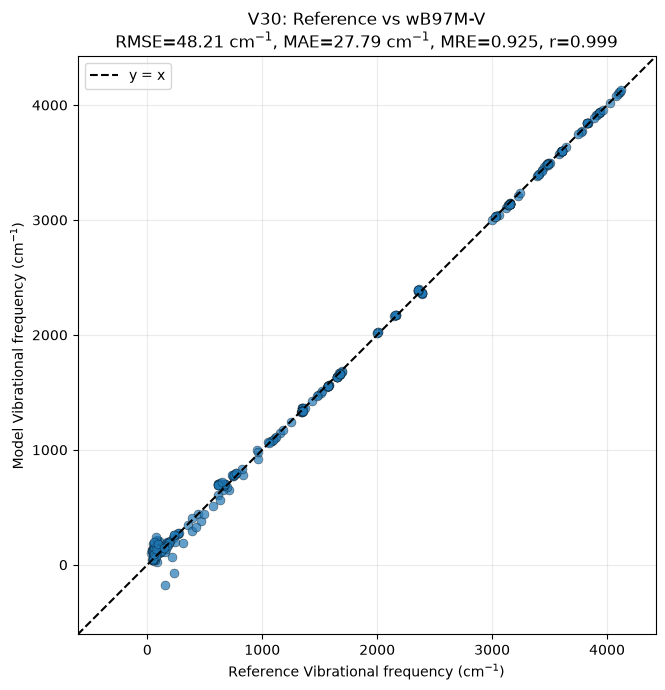

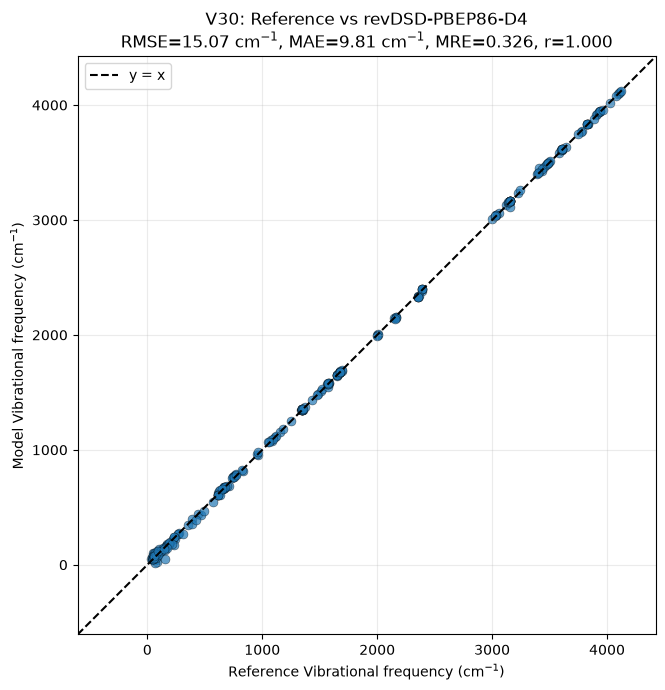

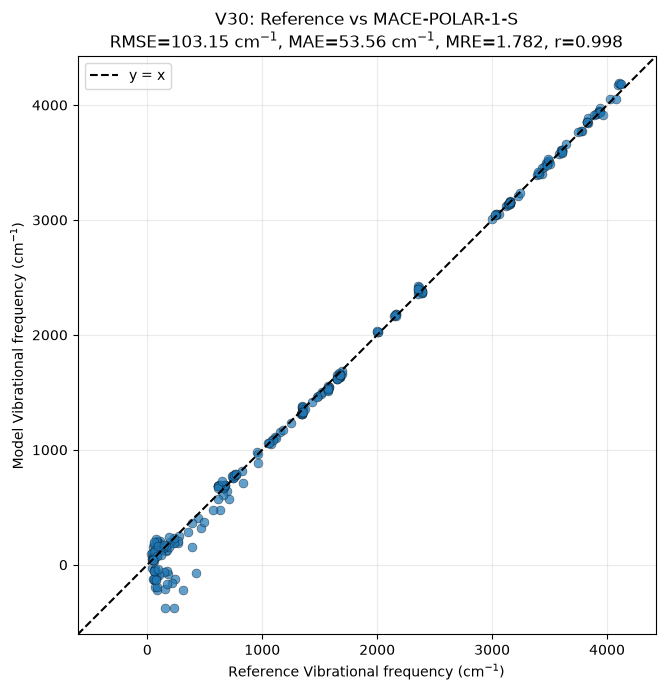

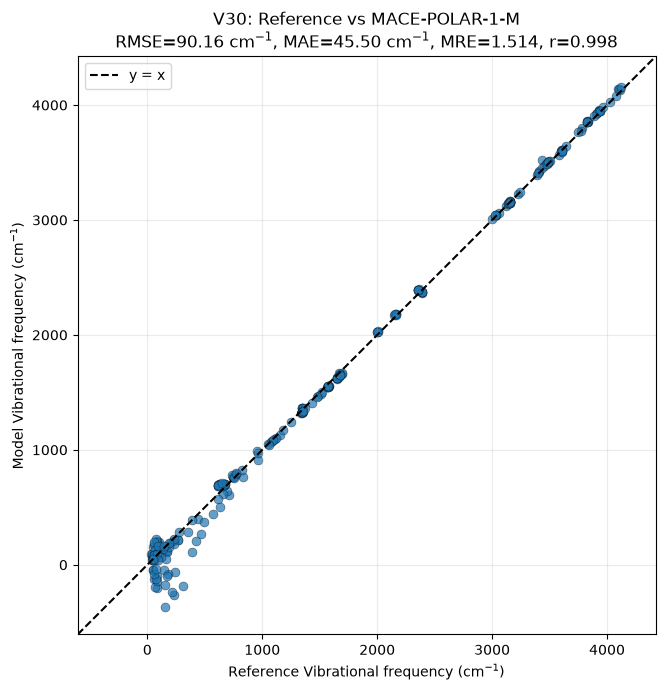

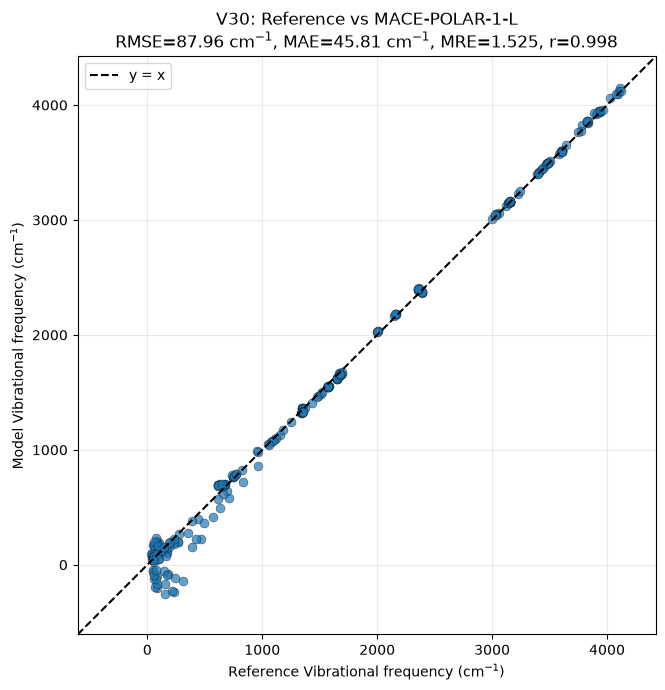

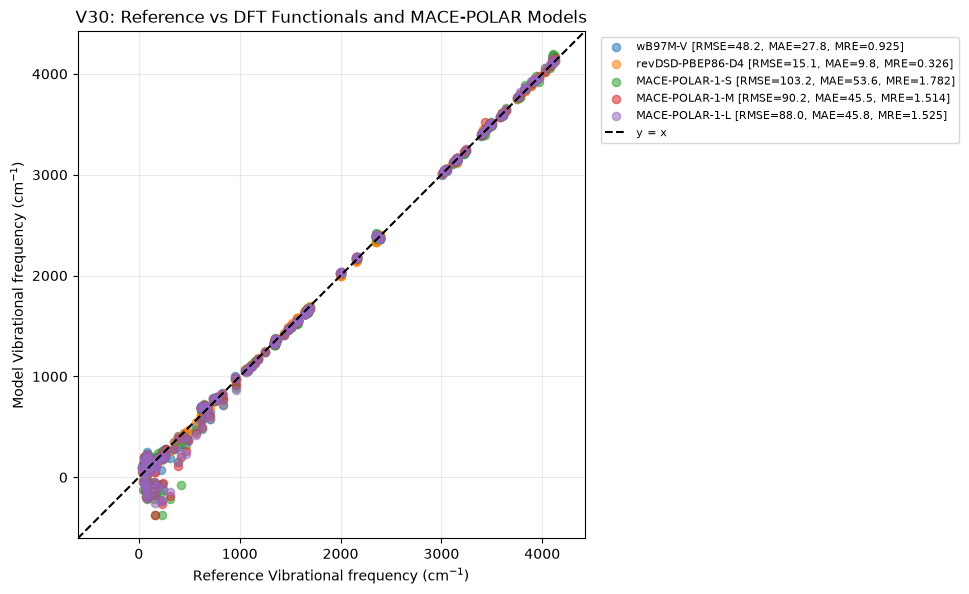

,Model,N,RMSE_cm-1,MAE_cm-1,MRE,Pearson_r
0,wB97M-V,275,48.208634,27.787819,0.924726,0.999388
1,revDSD-PBEP86-D4,275,15.066591,9.808376,0.326404,0.999940
2,mace-polar-1-s,275,103.150998,53.556929,1.782274,0.997580
3,mace-polar-1-m,275,90.163619,45.501520,1.514205,0.998062
4,mace-polar-1-l,275,87.959332,45.813113,1.524574,0.998157


In [2]:
# ============================================================
# CELL 2 — V30 CORRELATION PLOTS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A = ROOT / "Analysis"
FIG = A / "Figures" / "V30"
FIG.mkdir(parents=True, exist_ok=True)

# Load outputs generated by Cell 1
values_v30 = pd.read_csv(
    A / "Results_values_with_MACE_POLAR_V30_ALL3.csv",
    index_col=0
)

metrics_df = pd.read_csv(
    A / "V30_Frequency_RMSE_MAE_MRE_ALL_MODELS.csv"
)

models = {
    "wB97M-V": "wB97M-V",
    "revDSD-PBEP86-D4": "revDSD-PBEP86-D4",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L"
}

# Same axis limits for all plots
x = values_v30[["Reference", *models]].apply(pd.to_numeric, errors="coerce")
lo, hi = np.nanmin(x.values), np.nanmax(x.values)
pad = 0.05 * (hi - lo)
lo, hi = lo - pad, hi + pad

def metric(model):
    r = metrics_df.loc[metrics_df["Model"] == model].iloc[0]
    return r["RMSE_cm-1"], r["MAE_cm-1"], r["MRE"], r["Pearson_r"]

# ------------------------------------------------------------
# 1. INDIVIDUAL CORRELATION PLOTS
# ------------------------------------------------------------

for model, label in models.items():

    d = values_v30[["Reference", model]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    rmse, mae, mre, r = metric(model)

    plt.figure(figsize=(7, 7))
    plt.scatter(
        d["Reference"], d[model],
        s=42, alpha=0.7,
        edgecolors="black", linewidths=0.3
    )
    plt.plot([lo, hi], [lo, hi], "k--", label="y = x")

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(r"Reference Vibrational frequency (cm$^{-1}$)")
    plt.ylabel(r"Model Vibrational frequency (cm$^{-1}$)")

    plt.title(
        f"V30: Reference vs {label}\n"
        f"RMSE={rmse:.2f} cm$^{{-1}}$, "
        f"MAE={mae:.2f} cm$^{{-1}}$, "
        f"MRE={mre:.3f}, r={r:.3f}"
    )

    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIG / f"V30_Reference_vs_{model}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# ------------------------------------------------------------
# 2. COMBINED FIVE-MODEL CORRELATION PLOT
# ------------------------------------------------------------

plt.figure(figsize=(9, 8))

for model, label in models.items():

    d = values_v30[["Reference", model]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    rmse, mae, mre, r = metric(model)

    plt.scatter(
        d["Reference"], d[model],
        s=35, alpha=0.55,
        label=(
            f"{label} "
            f"[RMSE={rmse:.1f}, MAE={mae:.1f}, MRE={mre:.3f}]"
        )
    )

plt.plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="y = x")

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel(r"Reference Vibrational frequency (cm$^{-1}$)")
plt.ylabel(r"Model Vibrational frequency (cm$^{-1}$)")

plt.title(
    "V30: Reference vs DFT Functionals and MACE-POLAR Models"
)

plt.grid(alpha=0.25)
plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    FIG / "V30_Reference_vs_ALL_DFT_and_MACE_POLAR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(metrics_df)

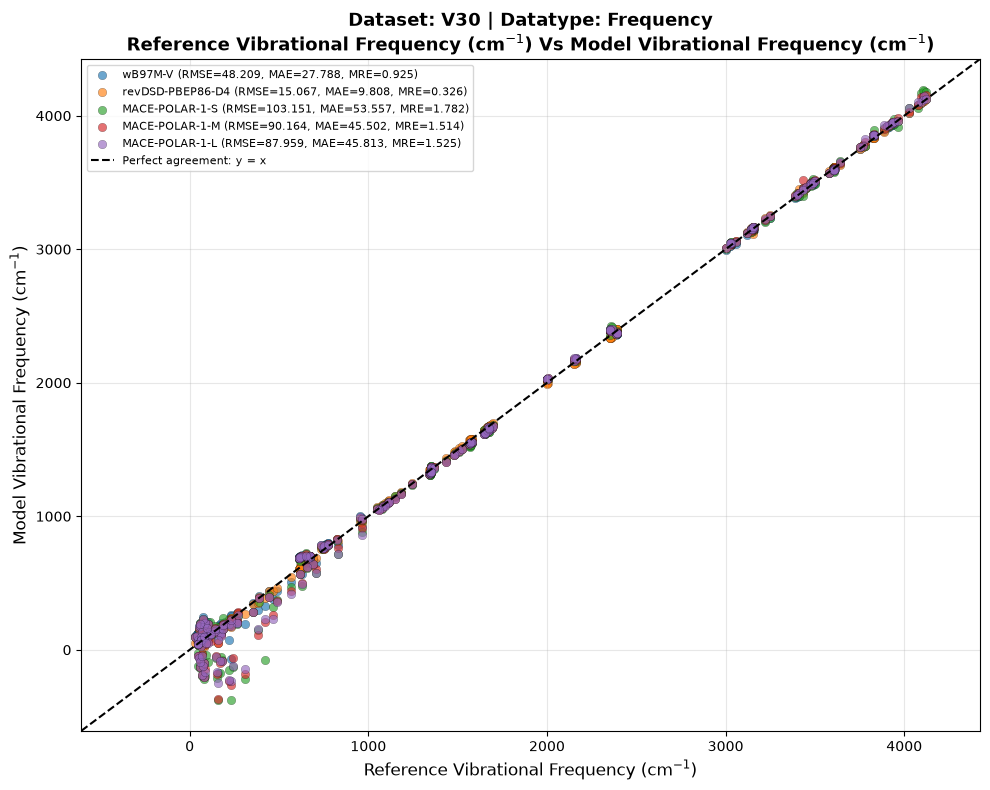

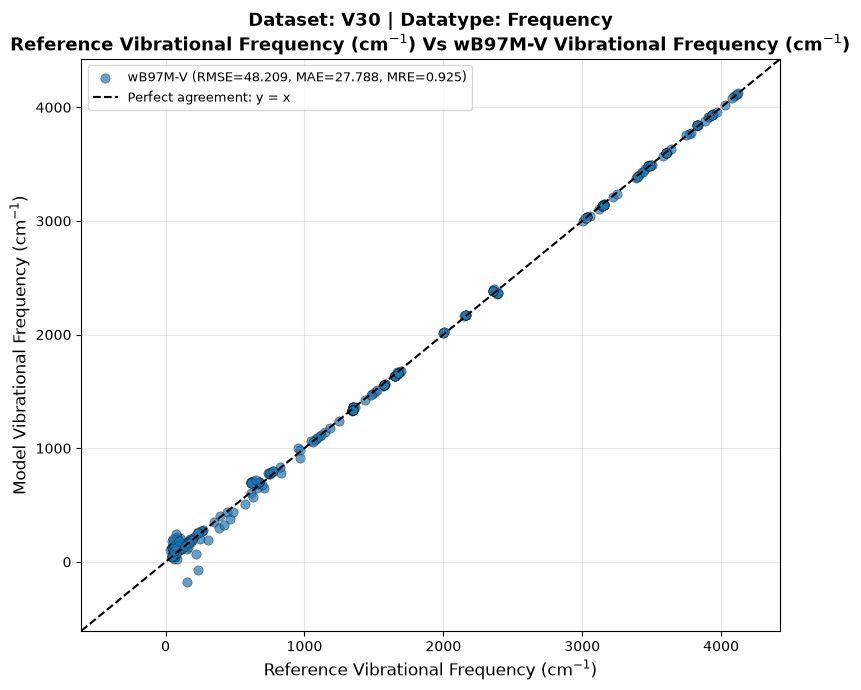

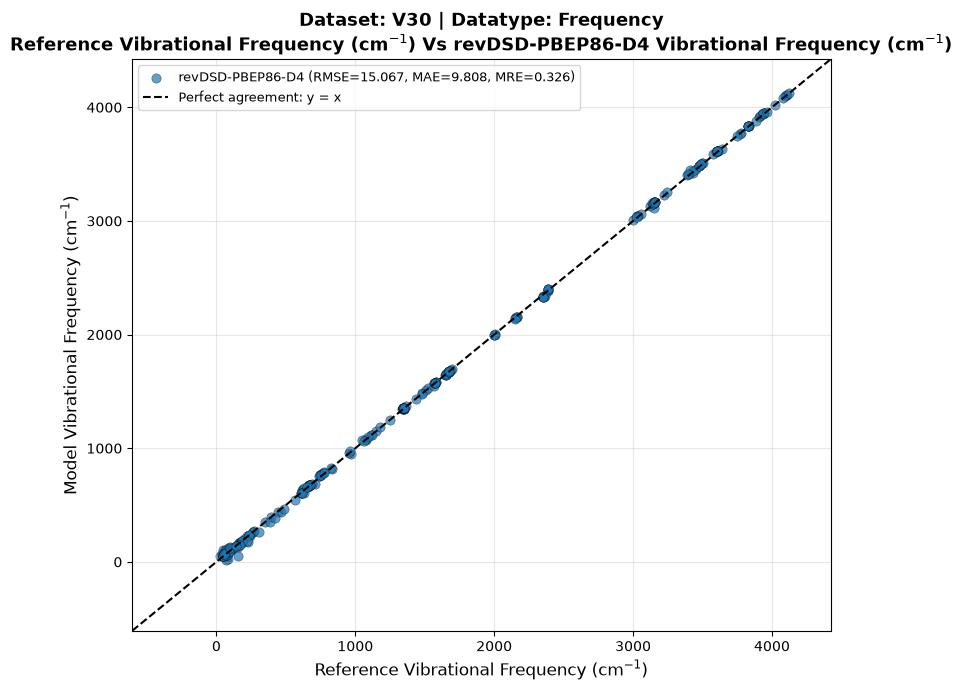

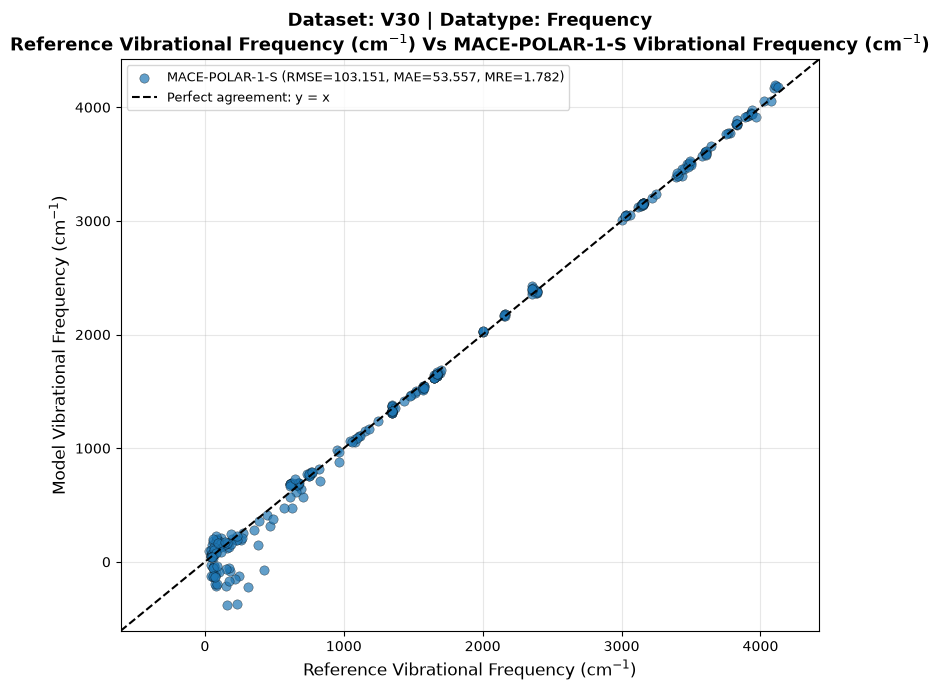

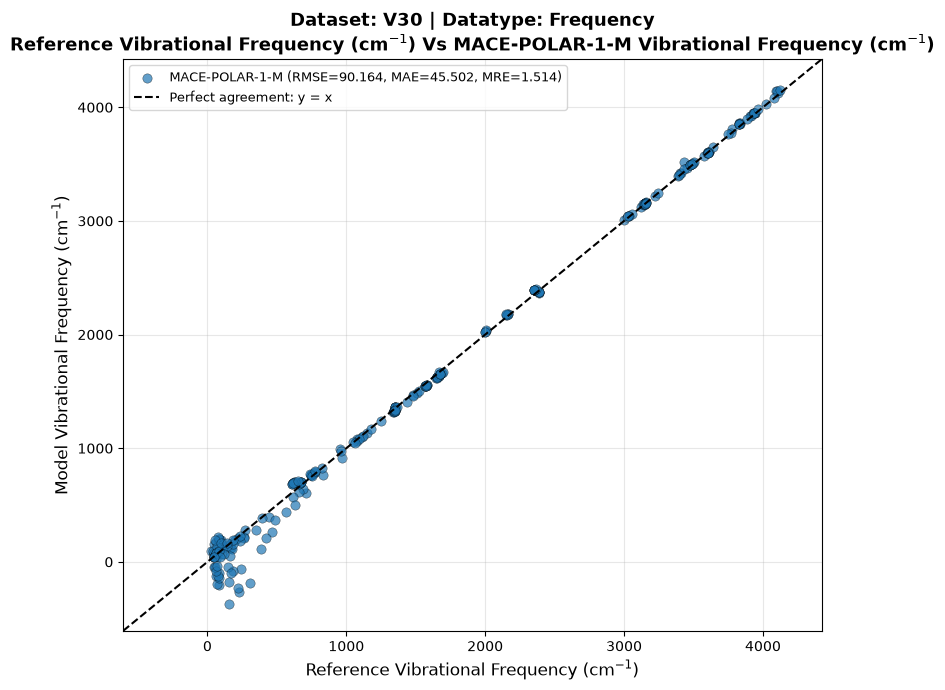

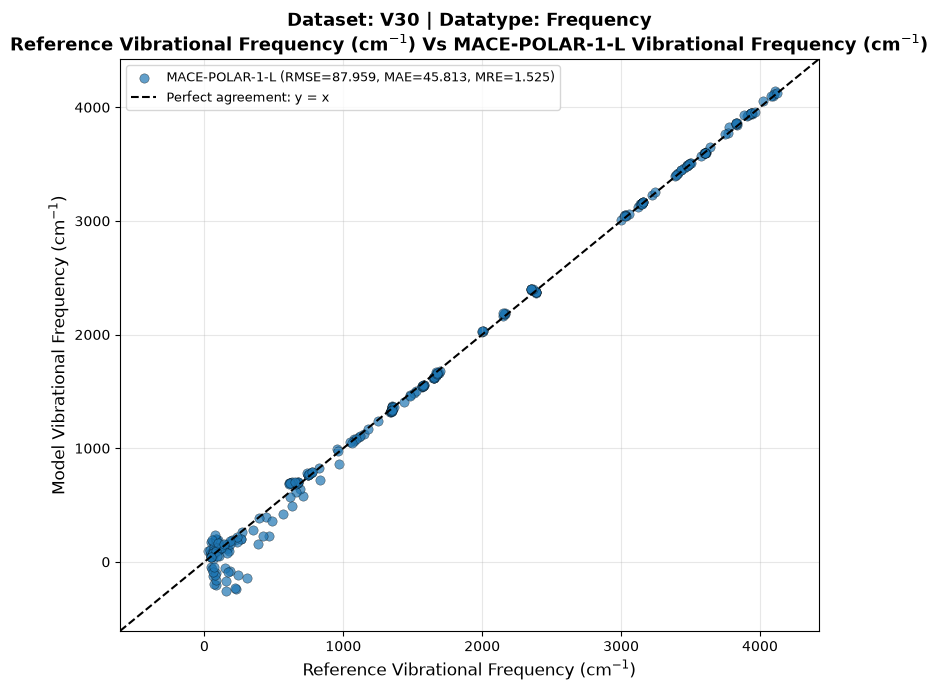

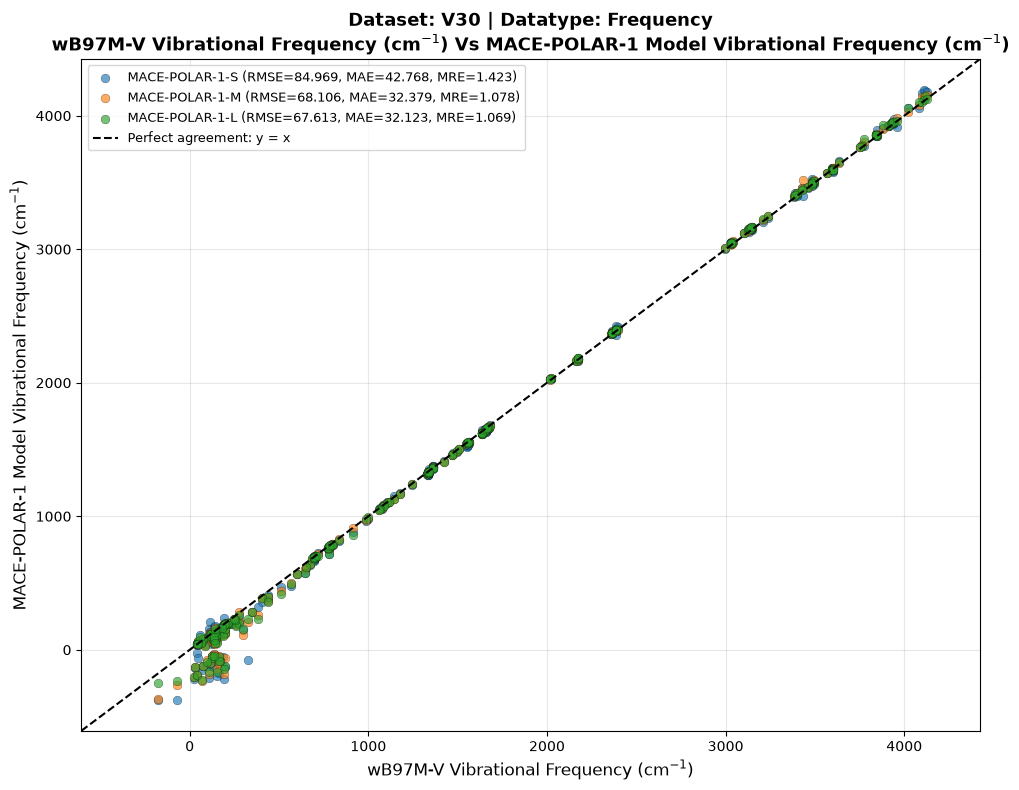

All 7 V30 correlation plots saved in:
c:\Users\91988\Documents\GitHub\Accurate-Prediction-of-Molecular-Properties-with-Polarisable-MACE\Analysis\Figures\V30


In [1]:
# ============================================================
# V30 FREQUENCY — 7 CORRELATION PLOTS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A = ROOT / "Analysis"
FIG = A / "Figures" / "V30"
FIG.mkdir(parents=True, exist_ok=True)

# Load V30 frequencies generated previously
df = pd.read_csv(
    A / "Results_values_with_MACE_POLAR_V30_ALL3.csv",
    index_col=0
)

standard = pd.read_csv(
    ROOT / "Info" / "Standard_errors.csv",
    index_col=0
)

STD = float(standard.loc["V30", "Metric"])

models = {
    "wB97M-V": "wB97M-V",
    "revDSD-PBEP86-D4": "revDSD-PBEP86-D4",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L"
}

# ------------------------------------------------------------
# Metric function
# ------------------------------------------------------------

def metrics(x, y):
    d = pd.DataFrame({"x": x, "y": y}).apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    e = d["y"] - d["x"]
    rmse = np.sqrt(np.mean(e**2))
    mae = np.mean(np.abs(e))
    mre = mae / STD
    r = np.corrcoef(d["x"], d["y"])[0, 1]

    return d, rmse, mae, mre, r


# ------------------------------------------------------------
# Common axis limits
# ------------------------------------------------------------

cols = ["Reference", *models]
v = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy()

lo, hi = np.nanmin(v), np.nanmax(v)
pad = 0.05 * (hi - lo)
lo, hi = lo - pad, hi + pad


# ------------------------------------------------------------
# Function for individual Reference-vs-Model plots
# ------------------------------------------------------------

def plot_single(model, label, number):

    d, rmse, mae, mre, r = metrics(
        df["Reference"], df[model]
    )

    plt.figure(figsize=(8, 7))

    plt.scatter(
        d["x"], d["y"],
        s=45, alpha=0.7,
        edgecolors="black",
        linewidths=0.3,
        label=(
            f"{label} "
            f"(RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})"
        )
    )

    plt.plot(
        [lo, hi], [lo, hi],
        "k--",
        label="Perfect agreement: y = x"
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)

    plt.xlabel(
        r"Reference Vibrational Frequency (cm$^{-1}$)",
        fontsize=12
    )

    plt.ylabel(
        r"Model Vibrational Frequency (cm$^{-1}$)",
        fontsize=12
    )

    plt.title(
        "Dataset: V30 | Datatype: Frequency\n"
        f"Reference Vibrational Frequency (cm$^{{-1}}$) "
        f"Vs {label} Vibrational Frequency (cm$^{{-1}}$)",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()

    plt.savefig(
        FIG / f"{number}_V30_Reference_vs_{model}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# PLOT 1 — REFERENCE vs ALL FIVE MODELS
# ============================================================

plt.figure(figsize=(10, 8))

for model, label in models.items():

    d, rmse, mae, mre, r = metrics(
        df["Reference"], df[model]
    )

    plt.scatter(
        d["x"], d["y"],
        s=38, alpha=0.65,
        edgecolors="black",
        linewidths=0.2,
        label=(
            f"{label} "
            f"(RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})"
        )
    )

plt.plot(
    [lo, hi], [lo, hi],
    "k--",
    label="Perfect agreement: y = x"
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)

plt.xlabel(
    r"Reference Vibrational Frequency (cm$^{-1}$)",
    fontsize=12
)

plt.ylabel(
    r"Model Vibrational Frequency (cm$^{-1}$)",
    fontsize=12
)

plt.title(
    "Dataset: V30 | Datatype: Frequency\n"
    "Reference Vibrational Frequency (cm$^{-1}$) "
    "Vs Model Vibrational Frequency (cm$^{-1}$)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(
    FIG / "1_V30_Reference_vs_All_Models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOTS 2–6 — INDIVIDUAL MODELS
# ============================================================

for number, (model, label) in enumerate(
    models.items(), start=2
):
    plot_single(model, label, number)


# ============================================================
# PLOT 7 — wB97M-V vs ALL THREE MACE-POLAR-1 MODELS
# ============================================================

mace_models = {
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L"
}

# Separate limits for wB97M-V-vs-MACE comparison
v2 = df[["wB97M-V", *mace_models]].apply(
    pd.to_numeric, errors="coerce"
).to_numpy()

lo2, hi2 = np.nanmin(v2), np.nanmax(v2)
pad2 = 0.05 * (hi2 - lo2)
lo2, hi2 = lo2 - pad2, hi2 + pad2

plt.figure(figsize=(10, 8))

for model, label in mace_models.items():

    d, rmse, mae, mre, r = metrics(
        df["wB97M-V"], df[model]
    )

    plt.scatter(
        d["x"], d["y"],
        s=40,
        alpha=0.65,
        edgecolors="black",
        linewidths=0.25,
        label=(
            f"{label} "
            f"(RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})"
        )
    )

plt.plot(
    [lo2, hi2], [lo2, hi2],
    "k--",
    label="Perfect agreement: y = x"
)

plt.xlim(lo2, hi2)
plt.ylim(lo2, hi2)

plt.xlabel(
    r"wB97M-V Vibrational Frequency (cm$^{-1}$)",
    fontsize=12
)

plt.ylabel(
    r"MACE-POLAR-1 Model Vibrational Frequency (cm$^{-1}$)",
    fontsize=12
)

plt.title(
    "Dataset: V30 | Datatype: Frequency\n"
    "wB97M-V Vibrational Frequency (cm$^{-1}$) "
    "Vs MACE-POLAR-1 Model Vibrational Frequency (cm$^{-1}$)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

plt.savefig(
    FIG / "7_V30_wB97M-V_vs_All_MACE-POLAR-1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"All 7 V30 correlation plots saved in:\n{FIG}")

# MACE-OMOL-0	models

In [2]:
# CELL 1 — Entire Frequency datatype with MACE-OMOL-0

from pathlib import Path
import re, gc, torch, numpy as np, pandas as pd
from tqdm.auto import tqdm
from ase.io import read
from mace.calculators import mace_omol

DATATYPE, TAG = "Frequency", "Frequency"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODELS = {
    "MACE-OMOL-0-100M": "extra_large",
    "MACE-OMOL-0-4M":
    "https://github.com/ACEsuit/mace-foundations/releases/download/mace_omol_0/mace-omol-0-extra-large-4M.model"
}

ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A, I, X = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files"

# Frequency dataset (currently V30)
info = pd.read_csv(I/"Datasets.csv", index_col=0)
sets = info.index[info["Datatype"].eq(DATATYPE)].tolist()
ev = pd.read_csv(I/"DatasetEval.csv", index_col=0)
ev = ev[ev["Dataset"].isin(sets)]

results_df = pd.read_csv(A/"Results_values.csv", index_col=0).loc[
    ev.index, ["Dataset", "Reference", "wB97M-V"]
].copy()

steps = pd.read_csv(I/"FD_stepsize.csv", index_col=0)["fd step"].reindex(ev.index)

def stoich(s):
    p = [x.strip() for x in str(s).split(",")]
    return [(float(p[i]), p[i+1]) for i in range(0, len(p), 2)]

def get_atoms(m):
    p = X/f"{m}.xyz"
    a, c = read(p), p.read_text().splitlines()[1]
    a.info["charge"] = float(re.search(r"charge=(-?\d+)", c).group(1))
    a.info["spin"] = float(re.search(r"multiplicity=(\d+)", c).group(1))
    return a

# All equilibrium and +/- displaced V30 structures
mols = sorted({m for s in ev["Stoichiometry"] for _, m in stoich(s)})
print(f"Datasets: {sets} | Points: {len(ev)} | Structures: {len(mols)} | Device: {DEVICE}")

# MACE-OMOL molecular energies (eV)
molE = pd.DataFrame(index=mols)

for name, model in MODELS.items():
    calc, E = mace_omol(model=model, device=DEVICE, default_dtype="float64"), {}
    for m in tqdm(mols, desc=name):
        atoms = get_atoms(m)
        atoms.calc = calc
        E[m] = float(atoms.get_potential_energy())
    molE[name] = pd.Series(E)
    del calc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

molE.to_csv(A/f"Molecule_Energies_MACE_OMOL_Datatype_{TAG}_ALL2.csv")

# GSCDB finite-difference energy -> vibrational frequency (cm^-1)
mass_conv = (1.66053907e-27/9.10938370e-31) * (1/0.529177211)**2
cm_conv = 4.55633528e-6

for name in MODELS:
    E = molE[name]
    dE = ev["Stoichiometry"].map(lambda s: sum(c*E[m] for c, m in stoich(s)))
    fc = (dE / 27.211386245988) / steps**2 / mass_conv
    results_df[name] = np.sign(fc) * np.sqrt(np.abs(fc)) / cm_conv

results_df.to_csv(A/f"Results_values_with_MACE_OMOL_Datatype_{TAG}_ALL2.csv")

# Per-dataset MAE, RMSE, MRE
cols = ["wB97M-V", *MODELS]
err = results_df[cols].sub(results_df["Reference"], axis=0)
group = results_df["Dataset"]
std = pd.read_csv(I/"Standard_errors.csv", index_col=0)["Metric"]

mae = err.abs().groupby(group).mean().reindex(sets)
rmse = err.pow(2).groupby(group).mean().pow(.5).reindex(sets)
mre = mae.div(std.reindex(sets), axis=0)

def save(df, metric):
    df = df.copy()
    df.insert(0, "Datatype", DATATYPE)
    df.index.name = "Dataset"
    df.to_csv(A/f"{metric}_MACE_OMOL_Datatype_{TAG}_ALL2.csv")
    return df

mae = save(mae, "Errors_per_set_MAE")
rmse = save(rmse, "Errors_per_set_RMSE")
mre = save(mre, "Relative_metric_per_set")

display(mae)
display(rmse)
display(mre)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


: 

In [ ]:
# CELL 2 — V30 / Frequency correlation plots

import matplotlib.pyplot as plt

FIG = A/"Figures"
FIG.mkdir(exist_ok=True)
UNIT = r"cm$^{-1}$"
STD = float(std.loc["V30"])

def metrics(x, y):
    d = results_df[[x, y]].dropna()
    e = d[y] - d[x]
    mae = np.mean(np.abs(e))
    return np.sqrt(np.mean(e**2)), mae, mae/STD

def plot(x, ys, file, xlabel, ylabel, title, size=(12, 9)):
    fig, ax = plt.subplots(figsize=size)
    vals = [results_df[x]]

    for y in ys:
        rmse, mae, mre = metrics(x, y)
        ax.scatter(
            results_df[x], results_df[y], s=45, alpha=.7,
            edgecolors="black", linewidths=.3,
            label=f"{y} (RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})"
        )
        vals.append(results_df[y])

    v = np.concatenate([z.dropna().to_numpy() for z in vals])
    lo, hi = v.min(), v.max()
    p = .05*(hi-lo)

    ax.plot([lo-p, hi+p], [lo-p, hi+p], "k--", lw=1.7,
            label="Perfect agreement: y = x")
    ax.set(xlim=(lo-p, hi+p), ylim=(lo-p, hi+p),
           xlabel=xlabel, ylabel=ylabel)
    ax.set_title(f"Dataset: V30 | Datatype: Frequency\n{title}",
                 fontsize=16, fontweight="bold")
    ax.grid(alpha=.3)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(FIG/file, dpi=300, bbox_inches="tight")
    plt.show()

# 1 — wB97M-V vs both MACE-OMOL-0 models
plot(
    "wB97M-V", list(MODELS),
    "1_V30_wB97M-V_vs_MACE-OMOL-0.png",
    f"wB97M-V Vibrational Frequency ({UNIT})",
    f"MACE-OMOL-0 Model Vibrational Frequency ({UNIT})",
    f"wB97M-V Vibrational Frequency ({UNIT}) Vs MACE-OMOL-0 Model Vibrational Frequency ({UNIT})"
)

# 2 — Reference vs all required models
plot(
    "Reference", ["wB97M-V", *MODELS],
    "2_V30_Reference_vs_All_Models.png",
    f"Reference Vibrational Frequency ({UNIT})",
    f"Model Vibrational Frequency ({UNIT})",
    f"Reference Vibrational Frequency ({UNIT}) Vs Model Vibrational Frequency ({UNIT})"
)

# 3 — Reference vs MACE-OMOL-0-100M
plot(
    "Reference", ["MACE-OMOL-0-100M"],
    "3_V30_Reference_vs_MACE-OMOL-0-100M.png",
    f"Reference Vibrational Frequency ({UNIT})",
    f"Model Vibrational Frequency ({UNIT})",
    f"Reference Vibrational Frequency ({UNIT}) Vs MACE-OMOL-0-100M Vibrational Frequency ({UNIT})",
    (10, 8)
)

# 4 — Reference vs MACE-OMOL-0-4M
plot(
    "Reference", ["MACE-OMOL-0-4M"],
    "4_V30_Reference_vs_MACE-OMOL-0-4M.png",
    f"Reference Vibrational Frequency ({UNIT})",
    f"Model Vibrational Frequency ({UNIT})",
    f"Reference Vibrational Frequency ({UNIT}) Vs MACE-OMOL-0-4M Vibrational Frequency ({UNIT})",
    (10, 8)
)

# 5 — Reference vs wB97M-V
plot(
    "Reference", ["wB97M-V"],
    "5_V30_Reference_vs_wB97M-V.png",
    f"Reference Vibrational Frequency ({UNIT})",
    f"Model Vibrational Frequency ({UNIT})",
    f"Reference Vibrational Frequency ({UNIT}) Vs wB97M-V Vibrational Frequency ({UNIT})",
    (10, 8)
)